Load the four zarrs produced by 

racmo_2km_downscaled/ff10m_rechunk_append.ipynb
racmo_2km_downscaled/t2m_rechunk_append.ipynb
racmo_2km_downscaled/snowmelt_rechunk_append.ipynb
and
racmo_2km_downscaled/precip_rechunk_append.ipynb

then merge them

then subset them spatially

then write the subsetted (rechunked) data to a zarr

e.g., 

In [1]:
import xarray as xr
import xarray as xr
import s3fs
from rechunker import rechunk
import zarr
from dask.diagnostics import ProgressBar
import dask


In [2]:
filenames = ['s3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/ff10m_all_06.zarr',
             's3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/precip_all_06.zarr',
             's3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/t2m_all_06.zarr',
             's3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/snowmelt_all_08.zarr']


filenames

['s3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/ff10m_all_06.zarr',
 's3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/precip_all_06.zarr',
 's3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/t2m_all_06.zarr',
 's3://nasa-cryo-scratch/jkingslake/Daily-2km-zarr/snowmelt_all_08.zarr']

In [3]:
dss = [xr.open_dataset(f, engine='zarr', chunks = {}) for f in filenames]


In [4]:
ds = xr.merge(dss)
ds

<xarray.Dataset> Size: 2TB
Dimensions:       (time: 17167, y: 2303, x: 2778)
Coordinates:
  * time          (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * y             (y) float32 9kB -2.232e+06 -2.23e+06 ... 2.37e+06 2.372e+06
  * x             (x) float32 11kB -2.731e+06 -2.729e+06 ... 2.821e+06 2.823e+06
Data variables:
    ff10mcorr     (time, y, x) float32 439GB dask.array<chunksize=(1, 2303, 2778), meta=np.ndarray>
    precipcorr    (time, y, x) float32 439GB dask.array<chunksize=(1, 2303, 2778), meta=np.ndarray>
    t2mcorr       (time, y, x) float32 439GB dask.array<chunksize=(1, 2303, 2778), meta=np.ndarray>
    snowmeltcorr  (time, y, x) float32 439GB dask.array<chunksize=(1, 2303, 2778), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Wed May 20 22:39:46 2026: cdo -f nc4 -z zip_5 copy ff10m/ff...
    institution:  IMAU (Brice Noel)
    netcdf:       4.9.0 of Jan  4 2023 16:53:07 $
    title:        Daily mean ff10m field at 2km (RACMO2.3p2 ANT27 ERA)

In [5]:
bbox = [-2383694.818402745,1218688.678871568,-2347942.4627997866,1243914.5502570888]

In [2]:
from dask.distributed import Client
client = Client()
client.cluster.scale(10)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jkingslake/proxy/8787/status,
Dashboard: /user/jkingslake/proxy/8787/status,Workers: 4
Total threads: 4,Total memory: 7.27 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40063,Workers: 4
Dashboard: /user/jkingslake/proxy/8787/status,Total threads: 4
Started: Just now,Total memory: 7.27 GiB
Comm: tcp://127.0.0.1:40555,Total threads: 1
Dashboard: /user/jkingslake/proxy/46655/status,Memory: 1.82 GiB
Nanny: tcp://127.0.0.1:39381,


2026-06-02 13:50:01,184 - tornado.application - ERROR - Uncaught exception GET /individual-progress/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='hub.cryointhecloud.com', method='GET', uri='/individual-progress/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/tornado/web.py", line 3388, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/srv/conda/envs/notebook/lib/python3.12/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol

In [49]:
# client.cluster.scale(20)


In [11]:
ds.sel(x = slice(bbox[0],bbox[2]), y = slice(bbox[1],bbox[3])).to_zarr('flask_racmo2km.zarr', mode='w')



/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 132.46 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [3]:
flask = xr.open_dataset('flask_racmo2km.zarr', engine='zarr', chunks={})

flask_rechunked = flask.chunk({'time': -1, 'y': -1, 'x': -1})

# make sure the encoding is the same as these chunks
for var in flask_rechunked.data_vars:
    print(var)
    da = flask_rechunked[var]
    da.encoding['chunks'] = (da.time.size, da.y.size, da.x.size)
    del da.encoding['preferred_chunks']
    print(flask_rechunked[var].encoding)
    

ff10mcorr
{'chunks': (17167, 12, 18), 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0), 'filters': None, 'missing_value': -1.0000000150474662e+30, '_FillValue': -1e+30, 'dtype': dtype('float32')}
precipcorr
{'chunks': (17167, 12, 18), 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0), 'filters': None, 'missing_value': -1.0000000150474662e+30, '_FillValue': -1e+30, 'dtype': dtype('float32')}
snowmeltcorr
{'chunks': (17167, 12, 18), 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0), 'filters': None, 'missing_value': -1.0000000150474662e+30, '_FillValue': -1e+30, 'dtype': dtype('float32')}
t2mcorr
{'chunks': (17167, 12, 18), 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0), 'filters': None, 'missing_value': -1.0000000150474662e+30, '_FillValue': -1e+30, 'dtype': dtype('float32')}


/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 22.38 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


<xarray.Dataset> Size: 59MB
Dimensions:       (time: 17167, y: 12, x: 18)
Coordinates:
  * time          (time) datetime64[ns] 137kB 1979-01-01 ... 2025-12-31
  * y             (y) float32 48B 1.22e+06 1.222e+06 ... 1.24e+06 1.242e+06
  * x             (x) float32 72B -2.383e+06 -2.381e+06 ... -2.349e+06
Data variables:
    ff10mcorr     (time, y, x) float32 15MB nan nan nan ... 1.346 1.355 1.371
    precipcorr    (time, y, x) float32 15MB 0.0 0.0 0.0 ... 0.1992 0.2109 0.2189
    snowmeltcorr  (time, y, x) float32 15MB 0.0 0.0 0.0 ... 6.937 6.921 6.929
    t2mcorr       (time, y, x) float32 15MB 267.3 268.0 268.2 ... 272.6 272.6
Attributes:
    CDI:          Climate Data Interface version 2.4.4 (https://mpimet.mpg.de...
    CDO:          Climate Data Operators version 2.4.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    grid:         Map Projection: Antarctic Polar Stereographic EPSG3031 - Ma...
    history:      Wed May 20 22:39:46 2026: cdo -f nc4 -z zip_5 copy ff10m/ff...
    institution:  IMAU (Brice Noel)
    netcdf:       4.9.0 of Jan  4 2023 16:53:07 $
    title:        Daily mean ff10m field at 2km (RACMO2.3p2 ANT27 ERA)

In [4]:
# # Write to new zarr store
flask_rechunked.to_zarr('flask_racmo2km_rechunked.zarr', mode='w', compute=False).compute()


In [5]:
flask_rechunked.ff10mcorr.encoding

{'chunks': (17167, 12, 18),
 'compressor': Blosc(cname='lz4', clevel=5, shuffle=SHUFFLE, blocksize=0),
 'filters': None,
 'missing_value': -1.0000000150474662e+30,
 '_FillValue': -1e+30,
 'dtype': dtype('float32')}

In [12]:
flask_reloaded = xr.open_dataset('flask_racmo2km_rechunked.zarr')

(array([  1815.,  14601.,  77157., 255026., 463966., 628879., 671156.,
        730471., 655864.,  98761.]),
 array([235.52412415, 239.70046997, 243.8768158 , 248.05316162,
        252.22950745, 256.40585327, 260.58218384, 264.75854492,
        268.93487549, 273.11123657, 277.28756714]),
 <BarContainer object of 10 artists>)

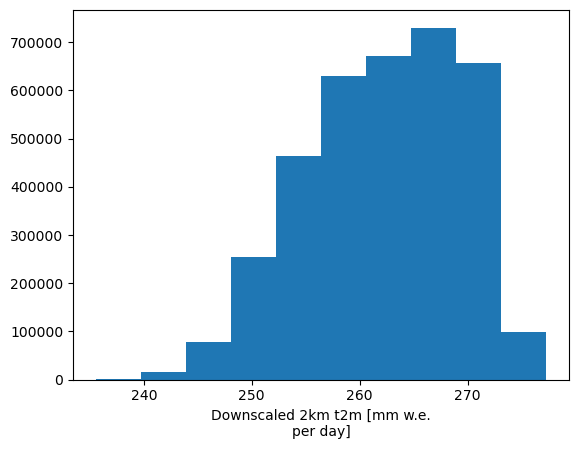

In [13]:
flask_reloaded.t2mcorr.plot()

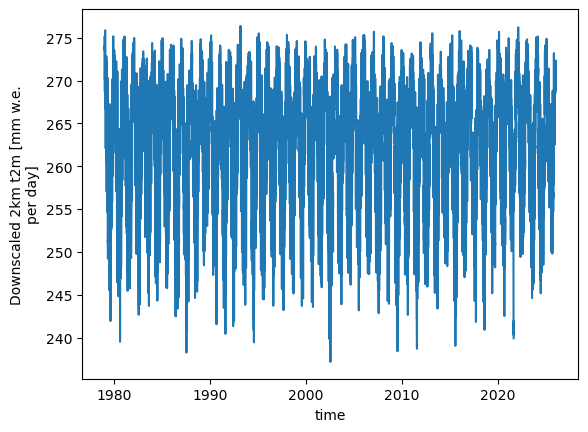

In [16]:
flask_reloaded.mean(['x','y']).t2mcorr.plot()